In [1]:
import os

from dotenv import load_dotenv

load_dotenv(override=True)

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

<div style="background:linear-gradient(90deg,#991b1b,#9a3412,#15803d); color:white; padding:24px 32px; border-radius:8px; width:97%;">

# 🎯 Deep Agent for Research

</div>

## 🗺️ 全景图

<img src="./assets/agent_header.png" width="800" style="display:block; margin-left:0;">

把前面学的东西 **拼到一起**:

- 📋 用 **TODOs** 追踪任务
- 📁 用 **files** 保存原始工具调用结果
- 🧱 用 **子 agent** 实现 context 隔离做研究

## 🔍 搜索工具

我们要造一个 **会"卸载 context"的搜索工具**:把网页原文落盘,主 agent 只看摘要。Manus 用的就是这套[长 trajectory 模式](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)。

### 🧩 核心组件

| 编号 | 组件 | 作用 |
|---|---|---|
| 1️⃣ | **`run_tavily_search`** | 调 Tavily API 跑搜索,可配置结果数和主题过滤 |
| 2️⃣ | **`summarize_webpage_content`** | 用 **轻量模型**(GPT-4o-mini)生成结构化摘要 → 文件名 + 关键学习点 |
| 3️⃣ | **`process_search_results`** | HTTP 拉网页 → `markdownify` 转 Markdown → 调用 summarize |
| 4️⃣ | **`tavily_search` tool** | 🌟 **主工具**:执行搜索 → 全文存文件 → 仅返回 mini summary → 用 `Command` 同步 files + messages |
| 5️⃣ | **`think_tool`** | 让 agent **结构化反思**:分析发现、评估缺口、规划下一步 |

#### 💰 为什么这套架构省 token?

把"详细的搜索结果"塞文件,把"agent 工作 context"保持**小而专注**。详细信息**按需取回**,日常推理时它不在 prompt 里。

> 💡 *2026 年观察*:**"工具产生大输出 → 落盘 + 返回摘要"** 已经是各家深度研究产品(Claude Code、Perplexity Pro Search、Devin)的标配。本节是这套模式的最小可运行版本。

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

### ⚠️ 改名提示

`create_react_agent` 在 **1.0 版本** 中从 LangGraph 迁到了 LangChain,并改名为 **`create_agent`**(视频是录制后才改的)。本课所有 notebook 都已更新到新接口。

</div>

In [4]:
%%writefile ../src/deep_agents_from_scratch/research_tools.py

import sys
sys.path.append("../src")
"""Research Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""
import os
from datetime import datetime
import uuid, base64

import httpx
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from markdownify import markdownify
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH
from deep_agents_from_scratch.state import DeepAgentState

# Summarization model 
summarization_model = init_chat_model(model="openai:gpt-4o-mini")
tavily_client = TavilyClient()

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def run_tavily_search(
    search_query: str, 
    max_results: int = 1, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> dict:
    """Perform search using Tavily API for a single query.

    Args:
        search_query: Search query to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        Search results dictionary
    """
    result = tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

    return result

def summarize_webpage_content(webpage_content: str) -> Summary:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Summary object with filename and summary
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary_and_filename = structured_model.invoke([
            HumanMessage(content=SUMMARIZE_WEB_SEARCH.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        return summary_and_filename
        
    except Exception:
        # Return a basic summary object on failure
        return Summary(
            filename="search_result.md",
            summary=webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content
        )


def process_search_results(results: dict) -> list[dict]:
    """Process search results by summarizing content where available.

    Args:
        results: Tavily search results dictionary

    Returns:
        List of processed results with summaries
    """
    processed_results = []

    # Create a client for HTTP requests with timeout
    HTTPX_CLIENT = httpx.Client(timeout=30.0)  # Add 30 second timeout

    for result in results.get('results', []):

        # Get url 
        url = result['url']

        # Read url with timeout and error handling
        try:
            response = HTTPX_CLIENT.get(url)
        
            if response.status_code == 200:
                # Convert HTML to markdown
                raw_content = markdownify(response.text)
                summary_obj = summarize_webpage_content(raw_content)
            else:
                # Use Tavily's generated summary
                raw_content = result.get('raw_content', '')
                summary_obj = Summary(
                    filename="URL_error.md",
                    summary=result.get('content', 'Error reading URL; try another search.')
                )
        except (httpx.TimeoutException, httpx.RequestError) as e:
            # Handle timeout or connection errors gracefully
            raw_content = result.get('raw_content', '')
            summary_obj = Summary(
                filename="connection_error.md",
                summary=result.get('content', f'Could not fetch URL (timeout/connection error). Try another search.')
            )

        # uniquify file names
        uid = base64.urlsafe_b64encode(uuid.uuid4().bytes).rstrip(b"=").decode("ascii")[:8]
        name, ext = os.path.splitext(summary_obj.filename)
        summary_obj.filename = f"{name}_{uid}{ext}"

        processed_results.append({
            'url': result['url'],
            'title': result['title'],
            'summary': summary_obj.summary,
            'filename': summary_obj.filename,
            'raw_content': raw_content,
        })

    return processed_results


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> Command:
    """Search web and save detailed results to files while returning minimal context.

    Performs web search and saves full content to files for context offloading.
    Returns only essential information to help the agent decide on next steps.

    Args:
        query: Search query to execute
        state: Injected agent state for file storage
        tool_call_id: Injected tool call identifier
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Command that saves full results to files and provides minimal summary
    """
    # Execute search
    search_results = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    ) 

    # Process and summarize results
    processed_results = process_search_results(search_results)
    
    # Save each result to a file and prepare summary
    files = state.get("files", {})
    saved_files = []
    summaries = []
    
    for i, result in enumerate(processed_results):
        # Use the AI-generated filename from summarization
        filename = result['filename']
        
        # Create file content with full details
        file_content = f"""# Search Result: {result['title']}

**URL:** {result['url']}
**Query:** {query}
**Date:** {get_today_str()}

## Summary
{result['summary']}

## Raw Content
{result['raw_content'] if result['raw_content'] else 'No raw content available'}
"""
        
        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")
    
    # Create minimal summary for tool message - focus on what was collected
    summary_text = f"""🔍 Found {len(processed_results)} result(s) for '{query}':

{chr(10).join(summaries)}

Files: {', '.join(saved_files)}
💡 Use read_file() to access full details when needed."""

    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(summary_text, tool_call_id=tool_call_id)
            ],
        }
    )

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

Overwriting ../src/deep_agents_from_scratch/research_tools.py


<div class="dark-title" style="background:linear-gradient(90deg,#5b21b6,#1e3a8a); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🤖 完整 Deep Agent

</div>

把前面所有学到的拼起来:

| 角色 | 持有的工具 |
|---|---|
| 🧑‍🔬 **子 agent (researcher)** | `tavily_search` + `think_tool` |
| 👨‍✈️ **父 agent (supervisor)** | 文件工具 (`ls` / `read_file` / `write_file`) + `think_tool` + `task` 派发工具 |

> 🔑 子 agent **只拿搜索 + 反思**,职责清晰;父 agent **管文件 + 派单**,负责协调。这就是 supervisor-worker 模式的最小骨架。

In [11]:
import sys
sys.path.append("../src")

from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS,
)
from deep_agents_from_scratch.research_tools import tavily_search, think_tool, get_today_str
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool
from deep_agents_from_scratch.todo_tools import write_todos, read_todos

# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-5", temperature=0.0)

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Tools
sub_agent_tools = [tavily_search, think_tool]
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": ["tavily_search", "think_tool"],
}

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

delegation_tools = [task_tool]
all_tools = sub_agent_tools + built_in_tools + delegation_tools  # search available to main agent for trivial cases

# Build prompt
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y"),
)

In [12]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 1-2 search tool calls maximum                                                        │
│  - **Normal queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Very Complex queries**: Use up to 5 search tool calls maximum                                              │
│  - **Always stop**: After 5 search tool calls if you c

In [13]:
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Research**: Proceed with research. The search tool will write files.                                      │
│  4. **Read**: Once you are satisfied with the collected sources, read the files and use them to answer the      │
│  user's question directly.                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                               

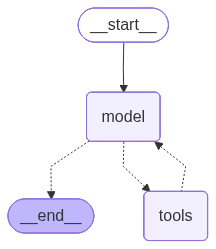

In [14]:
# Create agent
agent = create_agent(  #updated 1.0
    model, all_tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [15]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll research the Model Context Protocol (MCP) for you. Let me start by organizing this task.                   │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Delegate research on Model Context Protocol (MCP) to sub-agent",                              │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Review research findings and compile comprehensive overview",                                 │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_01XTM5S7mtAQk5vtybjLYV8U                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: ls                                                                                                │
│    Args: {}                                                                                                     │
│    ID: toolu_01RRazE3APkk5Z4mqxD4rcTC                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Delegate research on Model Context Protocol (MCP) to sub-agent', 'status':   │
│ 'in_progress'}, {'content': 'Review research findings and compile comprehensive overview', 'status':            │
│ 'pending'}]                                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "user_request.md",                                                                               │
│   "content": "# User Request\n\nGive me an overview of Model Context Protocol (MCP).\n"                         │
│ }                                                                                                               │
│    ID: toolu_01HhVB72AcDaChjJtbRjiDf5                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "subagent_type": "research-agent",                                                                            │
│   "description": "Research the Model Context Protocol (MCP). I need comprehensive information including: what   │
│ MCP is, its purpose and goals, key features and capabilities, how it works, who developed it, use cases and     │
│ applications, and its significance in the AI/LLM ecosystem."                                                    │
│ }                                                                                                               │
│    ID: toolu_01AZRkm9wRyFUCkwCHQFabTQ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: read_todos                                                                                        │
│    Args: {}                                                                                                     │
│    ID: toolu_01XNa8kyD7BbJwF5sstaniT1                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Current TODO List:                                                                                              │
│ 1. 🔄 Delegate research on Model Context Protocol (MCP) to sub-agent (in_progress)                              │
│ 2. ⏳ Review research findings and compile comprehensive overview (pending)                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Delegate research on Model Context Protocol (MCP) to sub-agent",                              │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Review research findings and compile comprehensive overview",                                 │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_01KtdcjWafM1oLYRG9vAvrNe                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Delegate research on Model Context Protocol (MCP) to sub-agent', 'status':   │
│ 'completed'}, {'content': 'Review research findings and compile comprehensive overview', 'status':              │
│ 'completed'}]                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ # Overview of Model Context Protocol (MCP)                                                                      │
│                                                                                                                 │
│ ## **What is MCP?**                                                                                             │
│                                                                                                                 │
│ The **Model Context Protocol (MCP)** is an open-source client-server protocol developed by **Anthropic** that   │
│ provides a standardized way to connect AI models and large language models (LLMs) with external tools,          │
│ services, and data sources. It represents a fundamental shift in AI architecture, enabling AI systems to move   │
│ beyond passive information consumption to become active participants that can execute tasks and interact with   │
│ real-world systems.                                                                                             │
│                                                                                                                 │
│ ## **Core Purpose**                                                                                             │
│                                                                                                                 │
│ MCP was created to solve the **N×M integration problem** in AI development. Previously, connecting AI           │
│ applications to various data sources required custom integrations for each combination—if you had N AI          │
│ applications and M data sources, you needed N×M custom connections. MCP replaces this with a universal standard │
│ where each side implements the protocol once and gains compatibility with all other implementations.            │
│                                                                                                                 │
│ ## **Key Features**                                                                                             │
│                                                                                                                 │
│ - **Dynamic Tool Discovery**: AI systems automatically discover and utilize available tools and resources       │
│ - **Structured Context Exchange**: Enables rich, context-aware communication between AI models and external     │
│ systems                                                                                                         │
│ - **Modular Client-Server Architecture**: Flexible design supporting diverse clients and servers                │
│ - **Stateful Workflows**: Maintains state across interactions for reliable multi-step tasks                     │
│ - **Security-First Design**: Includes OAuth 2.1 authentication, least privilege principles, and secure access   │
│ controls                                                                                                        │
│ - **Core Components**: Resources, prompts, and tools form the architectural foundation                          │
│                                                                                                                 │
│ ## **How It Works**                                                                                             │
│                                                                                                                 │
│ MCP uses a **client-server architecture**:                                                                      │
│                                                                                                                 │
│ - **Clients**: AI applications or LLMs that need external resources                                             │
│ - **Servers**: Provide access to specific tools, data s

In [16]:
result["messages"]

[HumanMessage(content='Give me an overview of Model Context Protocol (MCP).', additional_kwargs={}, response_metadata={}, id='57f7af49-057f-487c-8da4-e833d833977c'),
 AIMessage(content=[{'text': "I'll research the Model Context Protocol (MCP) for you. Let me start by organizing this task.", 'type': 'text'}, {'id': 'toolu_01XTM5S7mtAQk5vtybjLYV8U', 'caller': {'type': 'direct'}, 'input': {'todos': [{'content': 'Delegate research on Model Context Protocol (MCP) to sub-agent', 'status': 'in_progress'}, {'content': 'Review research findings and compile comprehensive overview', 'status': 'pending'}]}, 'name': 'write_todos', 'type': 'tool_use'}, {'id': 'toolu_01RRazE3APkk5Z4mqxD4rcTC', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'ls', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01LMTWJ77hkBBUjePzguDZx6', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'eph

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

🔭 **LangSmith Trace**:[查看本次执行](https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r)
<!-- https://smith.langchain.com/public/1df7a10e-1465-499c-a3e0-86c1d5429324/r -->

</div>

<div class="dark-title" style="background:linear-gradient(90deg,#15803d,#0e7490); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 📦 用 `deepagents` 包 —— 一行搞定

</div>

现在你 **彻底理解了底层套路**。

实战中可以直接用 [`deepagents`](https://github.com/hwchase17/deepagents) 这个包,把所有零件**封装成一个抽象**:

| 已内置 | 你需要提供 |
|---|---|
| 📁 文件系统工具 | 🧑‍🔬 子 agent 配置 |
| 📋 todo 工具 | 🛠️ 你想让子 agent 用的额外工具 |
| 🎯 task 派发工具 | |

> 💡 *2026 年观察*:`deepagents` 已经成为 LangChain 生态里"开箱即用"的 deep agent 起点。学完前面 4 节后,你已经知道它里面长什么样,**用它 = 不再黑盒**。

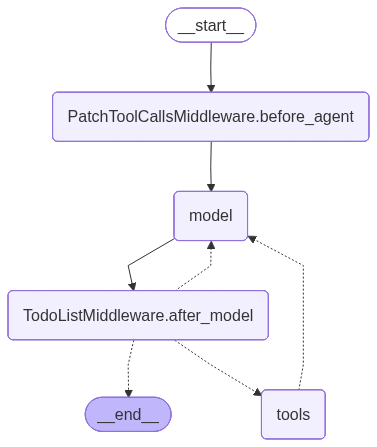

In [18]:
from deepagents import create_deep_agent
# updated since filming

# Create research sub-agent
research_sub_agent_2 = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": [tavily_search, think_tool],
}


agent = create_deep_agent(  # updated 
    tools=sub_agent_tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent_2],
    model=model,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [19]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an very brief overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an very brief overview of Model Context Protocol (MCP).                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Model Context Protocol (MCP) is an open protocol developed by Anthropic that enables AI models to securely      │
│ connect to external data sources and tools. It provides a standardized way for AI assistants to interact with   │
│ various systems—like databases, APIs, file systems, and business applications—without needing custom            │
│ integrations for each one.                                                                                      │
│                                                                                                                 │
│ **Key aspects:**                                                                                                │
│ - **Client-server architecture**: AI applications (clients) connect to MCP servers that expose specific         │
│ resources and tools                                                                                             │
│ - **Standardized interface**: Developers build MCP servers once, and they work with any MCP-compatible AI       │
│ application                                                                                                     │
│ - **Security-focused**: Provides controlled access to data and tools with clear permission boundaries           │
│ - **Extensible**: Supports resources (data), prompts (templates), and tools (actions)                           │
│                                                                                                                 │
│ Think of it as USB for AI—a universal standard that lets AI assistants plug into different data sources and     │
│ tools without custom wiring for each connection.                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

🔭 **LangSmith Trace**:[查看本次执行](https://smith.langchain.com/public/1d626d81-a102-4588-a2fb-cab40a7271f1/r)
<!-- https://smith.langchain.com/public/1ae2d7f6-f901-4ebd-b6c3-6657a55f88ae/r -->

</div>

<div class="dark-title" style="background:linear-gradient(90deg,#7c2d12,#9a3412); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🧪 公平对比:用同一 query 测 `deepagents` 包的真实速度

**问题**:cell 16 用了 `"very brief"`,LLM 跳过整套 deep agent 直接答了。这次用 **跟 cell 11 完全相同** 的 query,看真实耗时。

</div>

In [20]:
import time

# ⚠️ 关键:跟 cell 11 完全相同的 query,不加 "very brief"
query = "Give me an overview of Model Context Protocol (MCP)."

t0 = time.perf_counter()
result = agent.invoke({"messages": [{"role": "user", "content": query}]})
elapsed = time.perf_counter() - t0

# 统计执行规模
msgs = result["messages"]
tool_calls = sum(len(getattr(m, "tool_calls", []) or []) for m in msgs)

print(f"⏱️  耗时:        {elapsed:.1f} 秒")
print(f"📨 消息总数:      {len(msgs)} 条")
print(f"🔧 tool calls:   {tool_calls} 次")
print()
print("📊 参照系(cell 11 手写版):")
print("   耗时 ≈ 150 秒  /  消息 16 条  /  tool calls 14 次")
print()
print("🎯 解读:")
print("   • 若两边耗时接近 → 证明 deepagents 包没有黑魔法,只是工程封装")
print("   • 若 deepagents 显著更快 → 检查它是否走了完整 deep agent 流程")
print("   • tool calls = 0 → 又被 LLM 跳过了 deep agent 模式")

⏱️  耗时:        178.5 秒
📨 消息总数:      28 条
🔧 tool calls:   15 次

📊 参照系(cell 11 手写版):
   耗时 ≈ 150 秒  /  消息 16 条  /  tool calls 14 次

🎯 解读:
   • 若两边耗时接近 → 证明 deepagents 包没有黑魔法,只是工程封装
   • 若 deepagents 显著更快 → 检查它是否走了完整 deep agent 流程
   • tool calls = 0 → 又被 LLM 跳过了 deep agent 模式


In [21]:
# 想看完整 trace?运行这行:
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll research the Model Context Protocol (MCP) for you.                                                         │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research Model Context Protocol (MCP) - gather comprehensive information about what it is,    │
│ its purpose, key features, and how it works",                                                                   │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and provide overview to user",                                            │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_018HauaDfv7f2EaF7B4ju94x                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP overview what is it"                                                     │
│ }                                                                                                               │
│    ID: toolu_01CAA5zPLMoGDpKVppYbqJNq                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research Model Context Protocol (MCP) - gather comprehensive information     │
│ about what it is, its purpose, key features, and how it works', 'status': 'in_progress'}, {'content':           │
│ 'Synthesize findings and provide overview to user', 'status': 'pending'}]                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 🔍 Found 1 result(s) for 'Model Context Protocol MCP overview what is it':                                      │
│                                                                                                                 │
│ - mcp_protocol_overview_YhLEb56s.md: The Model Context Protocol (MCP) is an open-source standard facilitating   │
│ connections between AI applications and external systems, enhancing their capabilities by integrating data      │
│ sources, tools, and workflows. Key benefits include reduced development time for developers and improved        │
│ functionality for AI applications, allowing them to act on behalf of users across various contexts such as      │
│ calendars and databases....                                                                                     │
│                                                                                                                 │
│ Files: mcp_protocol_overview_YhLEb56s.md                                                                        │
│ 💡 Use read_file() to access full details when needed.                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP architecture components servers clients"                                 │
│ }                                                                                                               │
│    ID: toolu_01GR7ZkScbXGgw3iXHrF2qDR                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I notice the search results mention files but they're not being saved to the filesystem. Let me conduct more    │
│ comprehensive research using a subagent:                                                                        │
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "subagent_type": "research-agent",                                                                            │
│   "description": "Research the Model Context Protocol (MCP) comprehensively and provide a detailed report       │
│ covering:\n\n1. What MCP is - definition and purpose\n2. Who created it and when\n3. Core architecture and how  │
│ it works (client-server model, components)\n4. Key features and capabilities\n5. Main use cases and             │
│ benefits\n6. How it differs from traditional API integrations\n7. Current adoption and ecosystem\n\nPlease      │
│ provide a well-structured report with all the key information someone would need to understand MCP at a high    │
│ level."                                                                                                         │
│ }                                                                                                               │
│    ID: toolu_01UtHG9U6Nxmk5d6ctP6bPtR                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Based on my comprehensive research, I'll now provide you with a detailed report on the Model Context Protocol   │
│ (MCP):                                                                                                          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # **Model Context Protocol (MCP): Comprehensive Report**                                                        │
│                                                                                                                 │
│ ## **1. What MCP Is - Definition and Purpose**                                                                  │
│                                                                                                                 │
│ The **Model Context Protocol (MCP)** is an open standard designed to facilitate seamless integration between    │
│ large language models (LLMs) and various tools, data sources, and external systems. It provides a modular,      │
│ structured interface that enables AI agents to securely interact with external resources in a standardized way. │
│                                                                                                                 │
│ **Core Purpose:**                                                                                               │
│ - Eliminate the need for hardcoded, custom integrations for each tool or data source                            │
│ - Enable AI applications to dynamically discover and invoke tools                                               │
│ - Provide a universal communication layer between AI systems and enterprise resources                           │
│ - Enhance security and context management for AI-driven workflows                                               │
│                                                                                                                 │
│ ## **2. Creator and Timeline**                                                                                  │
│                                                                                                                 │
│ **Creator:** Anthropic                                                                                          │
│                                                                                                                 │
│ **Launch Timeline:** Based on the research findings, MCP has experienced rapid growth within approximately one  │
│ year of its launch (specific launch date appears to be in 2024, with significant adoption tracking through      │
│ 2025). The protocol has evolved from initial limitations to become a foundational communication layer for       │
│ modern AI software.                                                                                             │
│                                                                                                                 │
│ **Key Milestones:**                                                                                             │
│ - Initial launch by Anthropic                                                                                   │
│ - Early adoption phase with some limitations                                                                    │
│ - Support from major tech players including OpenAI and Google                                                   │
│ - Rapid ecosystem growth with transparent vulnerability management                                              │
│ - Evolution into an industry standard                  

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research Model Context Protocol (MCP) - gather comprehensive information about what it is,    │
│ its purpose, key features, and how it works",                                                                   │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings and provide overview to user",                                            │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: toolu_01CrcpwykrqDKnzFA7DJGRVY                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research Model Context Protocol (MCP) - gather comprehensive information     │
│ about what it is, its purpose, key features, and how it works', 'status': 'completed'}, {'content': 'Synthesize │
│ findings and provide overview to user', 'status': 'completed'}]                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## Model Context Protocol (MCP) Overview                                                                        │
│                                                                                                                 │
│ **Model Context Protocol (MCP)** is an open standard created by **Anthropic** that enables seamless integration │
│ between AI applications (particularly large language models) and external tools, data sources, and systems.     │
│                                                                                                                 │
│ ### **What It Is**                                                                                              │
│ MCP provides a standardized communication layer that allows AI agents to dynamically discover and interact with │
│ external resources without requiring custom, hardcoded integrations for each tool or data source.               │
│                                                                                                                 │
│ ### **Core Architecture**                                                                                       │
│ MCP uses a **client-server model** with three components:                                                       │
│ - **Hosts**: AI applications/LLM platforms                                                                      │
│ - **Clients**: Interface components connecting hosts to servers                                                 │
│ - **Servers**: Services exposing tools, data sources, or capabilities                                           │
│                                                                                                                 │
│ ### **Key Features**                                                                                            │
│ - **Dynamic Tool Discovery**: AI agents automatically find and use available tools at runtime                   │
│ - **Modular Design**: Plug-and-play architecture for easy integration                                           │
│ - **Enhanced Security**: Transparent vulnerability management and controlled access                             │
│ - **Context Management**: Intelligent context passing between AI and tools                                      │
│ - **Multi-language Support**: Platform-agnostic implementation                                                  │
│                                                                                                                 │
│ ### **Main Benefits**                                                                                           │
│ - **Reduced Complexity**: Single standard replaces multiple custom integrations                                 │
│ - **Lower Technical Debt**: Eliminates maintenance overhead of custom APIs                                      │
│ - **Faster Development**: Accelerates AI application deployment                                                 │
│ - **Better Scalability**: Easy to add new capabilities without rebuilding integrations                          │
│                                                                                                                 │
│ ### **MCP vs Traditional APIs**                                                                                 │
│ Unlike traditional APIs that require hardcoded, static integrations, MCP offers:                                │
│ - Runtime discovery vs. pre-configuration                                                                       │
│ - AI-optimized context awareness                                                                                │
│ - Unified interface across all tools                                                                            │
│ - Standardized maintenance vs. custom code upkeep      

In [22]:
result["messages"]

[HumanMessage(content='Give me an overview of Model Context Protocol (MCP).', additional_kwargs={}, response_metadata={}),
 AIMessage(content=[{'text': "I'll research the Model Context Protocol (MCP) for you.", 'type': 'text'}, {'id': 'toolu_018HauaDfv7f2EaF7B4ju94x', 'caller': {'type': 'direct'}, 'input': {'todos': [{'content': 'Research Model Context Protocol (MCP) - gather comprehensive information about what it is, its purpose, key features, and how it works', 'status': 'in_progress'}, {'content': 'Synthesize findings and provide overview to user', 'status': 'pending'}]}, 'name': 'write_todos', 'type': 'tool_use'}, {'id': 'toolu_01CAA5zPLMoGDpKVppYbqJNq', 'caller': {'type': 'direct'}, 'input': {'query': 'Model Context Protocol MCP overview what is it'}, 'name': 'tavily_search', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01XsqNmPH1WazBa9WEEzxhqn', 'container': None, 'model': 'claude-sonnet-4-6', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_se